In [1]:
# Notebook 05 - Task 2: Vietnam Stock Price Prediction
# Tasks:
# 2.1 Vietnam multi-feature next-day prediction
# 2.2 Vietnam kth-day forecast
# 2.3 Vietnam k consecutive days forecast

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
# ============================================================
# 1. Load Vietnam stock dataset
# ============================================================

vn_path = "../data/vietnam/stock-historical-data"

ticker = "FPT"
ticker_file = "FPT-VNINDEX-History.csv"

df = pd.read_csv(os.path.join(vn_path, ticker_file))

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df["TradingDate"] = pd.to_datetime(
    df["TradingDate"],
    errors="coerce"
)

df = df.dropna(subset=["TradingDate"])

df = df.sort_values("TradingDate").reset_index(drop=True)

df.head()

,Open,High,Low,Close,Volume,TradingDate
0,15710.0,15710.0,15710.0,15710.0,83530,2006-12-13
1,16495.0,16495.0,16495.0,16495.0,280710,2006-12-14
2,17320.0,17320.0,17320.0,17320.0,265300,2006-12-15
3,18184.0,18184.0,18184.0,18184.0,215790,2006-12-18
4,19087.0,19087.0,19087.0,19087.0,137520,2006-12-19


In [3]:
# ============================================================
# 2. Basic data checking
# ============================================================

print("Dataset shape:", df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

df.describe()

Dataset shape: (4038, 6)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4038 entries, 0 to 4037
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Open         4038 non-null   float64       
 1   High         4038 non-null   float64       
 2   Low          4038 non-null   float64       
 3   Close        4038 non-null   float64       
 4   Volume       4038 non-null   int64         
 5   TradingDate  4038 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 189.4 KB
None

Missing values:
Open           0
High           0
Low            0
Close          0
Volume         0
TradingDate    0
dtype: int64


,Open,High,Low,Close,Volume,TradingDate
count,4038.000000,4038.000000,4038.000000,4038.000000,4.038000e+03,4038
mean,22482.188955,22734.517088,22245.286528,22481.119366,8.841220e+05,2015-01-26 19:50:22.288261
min,2807.000000,2958.000000,2807.000000,2892.000000,0.000000e+00,2006-12-13 00:00:00
25%,8071.750000,8144.000000,7998.250000,8049.000000,2.229500e+05,2011-01-06 06:00:00
50%,13844.000000,13944.000000,13725.500000,13828.000000,5.303100e+05,2015-01-27 12:00:00
75%,25228.250000,25491.000000,24938.250000,25154.000000,1.227910e+06,2019-02-14 18:00:00
max,95099.000000,97058.000000,94038.000000,95181.000000,8.399400e+06,2023-02-28 00:00:00
std,22150.863332,22429.598862,21885.200907,22152.826702,9.529551e+05,NaN


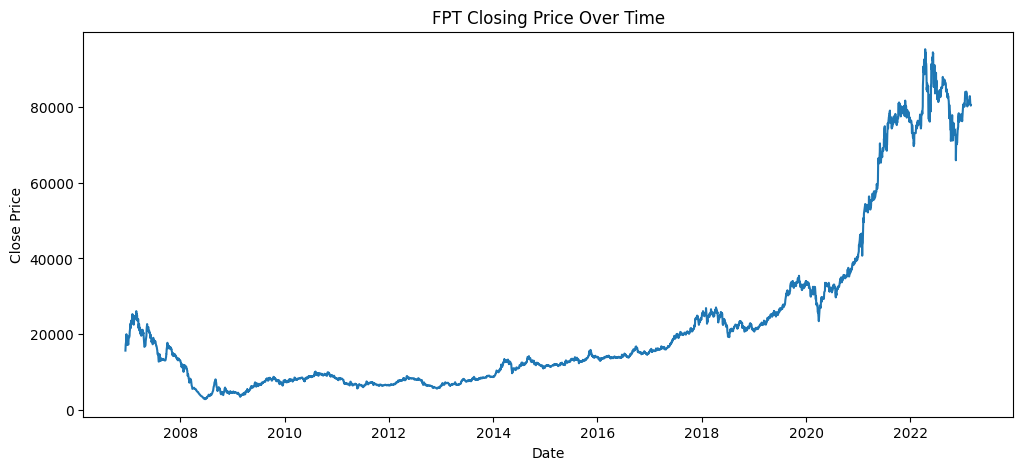

In [4]:
# ============================================================
# 3. Plot original closing price
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["TradingDate"],
    df["Close"]
)

plt.title(f"{ticker} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.savefig(
    "../results/figures/task2_vietnam_original_close_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
# ============================================================
# 4. Select multi-feature input
# ============================================================

features = [
    "Low",
    "Open",
    "Volume",
    "High",
    "Close"
]

target_col = "Close"

close_index = features.index(target_col)

data = df[features].copy()

data.head()

,Low,Open,Volume,High,Close
0,15710.0,15710.0,83530,15710.0,15710.0
1,16495.0,16495.0,280710,16495.0,16495.0
2,17320.0,17320.0,265300,17320.0,17320.0
3,18184.0,18184.0,215790,18184.0,18184.0
4,19087.0,19087.0,137520,19087.0,19087.0


In [6]:
# ============================================================
# 5. Normalize data
# ============================================================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)

Scaled data shape: (4038, 5)


In [7]:
# ============================================================
# 6. Helper functions
# ============================================================

def chronological_split(X, y, train_ratio=0.7, val_ratio=0.15):
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )


def build_cnn_model(window_size, num_features, output_size=1):
    model = Sequential()

    model.add(
        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            input_shape=(window_size, num_features)
        )
    )

    model.add(MaxPooling1D(pool_size=2))

    model.add(Dropout(0.2))

    model.add(Flatten())

    model.add(Dense(64, activation="relu"))

    model.add(Dropout(0.2))

    model.add(Dense(output_size))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="mse",
        metrics=["mae"]
    )

    return model


def plot_training_history(history, title, save_path):
    plt.figure(figsize=(12, 5))

    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.yscale("log")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.legend()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


def evaluate_prediction(y_true, y_pred, title, save_path):
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    print(title)
    print("RMSE:", rmse)
    print("MAE:", mae)

    plt.figure(figsize=(12, 5))

    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")

    plt.title(title)
    plt.xlabel("Test Sample")
    plt.ylabel("Normalized Close Price")
    plt.legend()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return rmse, mae

In [8]:
# ============================================================
# 7. Early stopping
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [9]:
# ============================================================
# Task 2.1 - Vietnam multi-feature next-day prediction
# ============================================================

window_size = 30

X_2_1 = []
y_2_1 = []

for i in range(window_size, len(scaled_data)):
    X_2_1.append(
        scaled_data[i - window_size:i]
    )

    y_2_1.append(
        scaled_data[i, close_index]
    )

X_2_1 = np.array(X_2_1)
y_2_1 = np.array(y_2_1)

print("Task 2.1 X shape:", X_2_1.shape)
print("Task 2.1 y shape:", y_2_1.shape)

Task 2.1 X shape: (4008, 30, 5)
Task 2.1 y shape: (4008,)


In [10]:
X_train_2_1, X_val_2_1, X_test_2_1, \
y_train_2_1, y_val_2_1, y_test_2_1 = chronological_split(
    X_2_1,
    y_2_1
)

print("Train:", X_train_2_1.shape, y_train_2_1.shape)
print("Validation:", X_val_2_1.shape, y_val_2_1.shape)
print("Test:", X_test_2_1.shape, y_test_2_1.shape)

Train: (2805, 30, 5) (2805,)
Validation: (601, 30, 5) (601,)
Test: (602, 30, 5) (602,)


In [11]:
model_2_1 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=1
)

model_2_1.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,497 (228.50 KB)

 Trainable params: 58,497 (228.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_2_1 = model_2_1.fit(
    X_train_2_1,
    y_train_2_1,
    validation_data=(
        X_val_2_1,
        y_val_2_1
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 7.8934e-04 - mae: 0.0191 - val_loss: 6.2852e-04 - val_mae: 0.0224
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5498e-04 - mae: 0.0128 - val_loss: 0.0016 - val_mae: 0.0379
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6537e-04 - mae: 0.0110 - val_loss: 7.8111e-04 - val_mae: 0.0252
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4904e-04 - mae: 0.0106 - val_loss: 5.7681e-04 - val_mae: 0.0216
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0178e-04 - mae: 0.0094 - val_loss: 0.0017 - val_mae: 0.0387
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8501e-04 - mae: 0.0091 - val_loss: 2.3661e-04 - val_mae: 0.0109
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7773e-04 - mae: 0.0087 - val_loss: 1.9797e-04 - val_mae: 0.0117
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5126e-04 - mae: 0.0080 - val_loss: 2.6205e-04 - val_mae: 0.0141
Epoch 9/

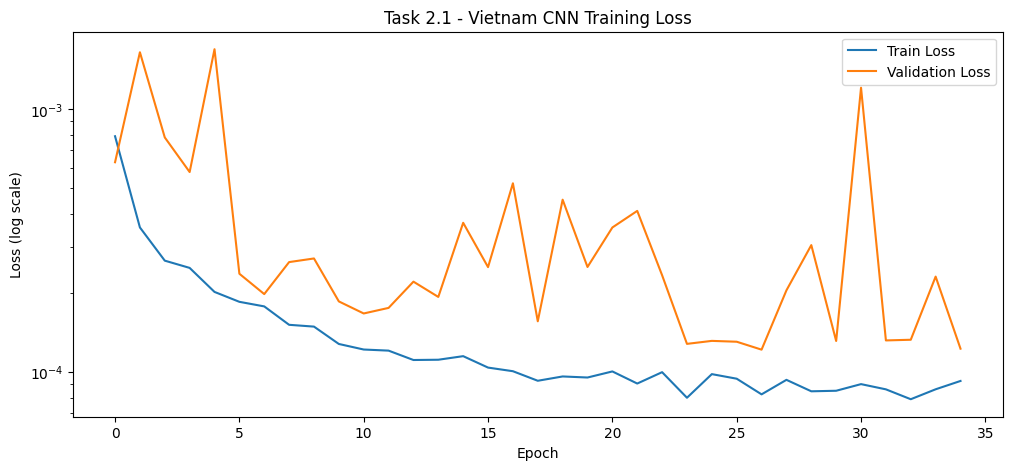

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Task 2.1 - Vietnam CNN Next-Day Prediction
RMSE: 0.04650711633142017
MAE: 0.03761064126933617


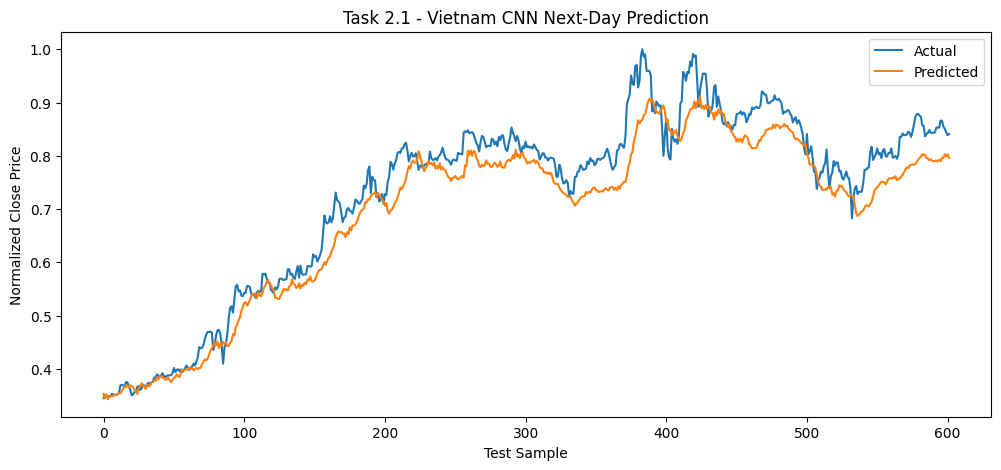

In [13]:
plot_training_history(
    history_2_1,
    "Task 2.1 - Vietnam CNN Training Loss",
    "../results/figures/task2_1_cnn_loss_curve.png"
)

pred_2_1 = model_2_1.predict(X_test_2_1)

rmse_2_1, mae_2_1 = evaluate_prediction(
    y_test_2_1,
    pred_2_1,
    "Task 2.1 - Vietnam CNN Next-Day Prediction",
    "../results/figures/task2_1_cnn_actual_vs_predicted.png"
)

model_2_1.save("../models/task2_1_vietnam_cnn.keras")

In [14]:
# ============================================================
# Task 2.2 - Vietnam kth-day forecast
# ============================================================

def create_kth_day_dataset(
    scaled_data,
    window_size,
    close_index,
    k
):
    X = []
    y = []

    for i in range(window_size, len(scaled_data) - k + 1):
        X.append(
            scaled_data[i - window_size:i]
        )

        y.append(
            scaled_data[i + k - 1, close_index]
        )

    return np.array(X), np.array(y)

In [15]:
k_day = 7

X_2_2, y_2_2 = create_kth_day_dataset(
    scaled_data=scaled_data,
    window_size=window_size,
    close_index=close_index,
    k=k_day
)

print("Task 2.2 X shape:", X_2_2.shape)
print("Task 2.2 y shape:", y_2_2.shape)

Task 2.2 X shape: (4002, 30, 5)
Task 2.2 y shape: (4002,)


In [16]:
X_train_2_2, X_val_2_2, X_test_2_2, \
y_train_2_2, y_val_2_2, y_test_2_2 = chronological_split(
    X_2_2,
    y_2_2
)

print("Train:", X_train_2_2.shape, y_train_2_2.shape)
print("Validation:", X_val_2_2.shape, y_val_2_2.shape)
print("Test:", X_test_2_2.shape, y_test_2_2.shape)

Train: (2801, 30, 5) (2801,)
Validation: (600, 30, 5) (600,)
Test: (601, 30, 5) (601,)


In [17]:
model_2_2 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=1
)

model_2_2.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 28, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,497 (228.50 KB)

 Trainable params: 58,497 (228.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_2_2 = model_2_2.fit(
    X_train_2_2,
    y_train_2_2,
    validation_data=(
        X_val_2_2,
        y_val_2_2
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 7.2699e-04 - mae: 0.0183 - val_loss: 0.0011 - val_mae: 0.0282
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.5415e-04 - mae: 0.0132 - val_loss: 5.8809e-04 - val_mae: 0.0208
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0691e-04 - mae: 0.0120 - val_loss: 5.0108e-04 - val_mae: 0.0184
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.8100e-04 - mae: 0.0114 - val_loss: 6.4492e-04 - val_mae: 0.0217
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2847e-04 - mae: 0.0104 - val_loss: 4.4012e-04 - val_mae: 0.0149
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1071e-04 - mae: 0.0101 - val_loss: 6.6522e-04 - val_mae: 0.0225
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0702e-04 - mae: 0.0099 - val_loss: 4.0410e-04 - val_mae: 0.0166
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8908e-04 - mae: 0.0094 - val_loss: 7.5618e-04 - val_mae: 0.0243


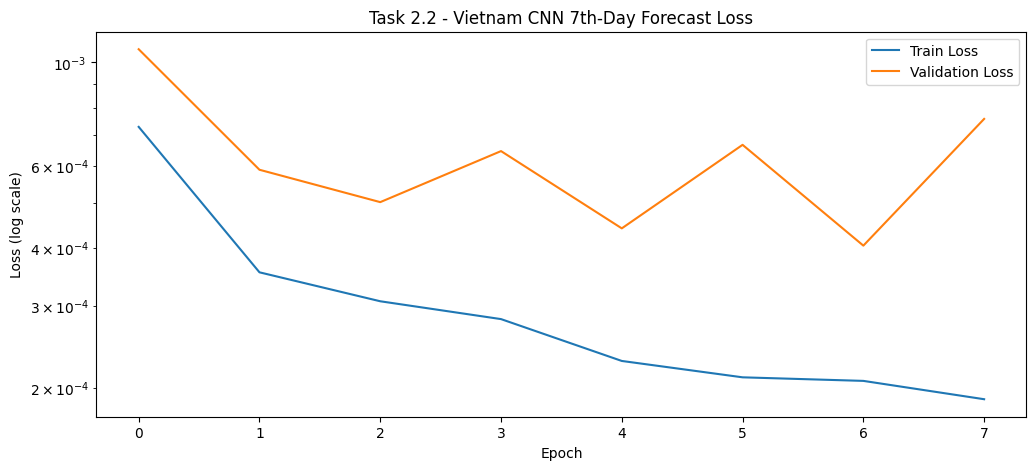

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Task 2.2 - Vietnam CNN 7th-Day Forecast
RMSE: 0.0925213564073291
MAE: 0.08085640160934511


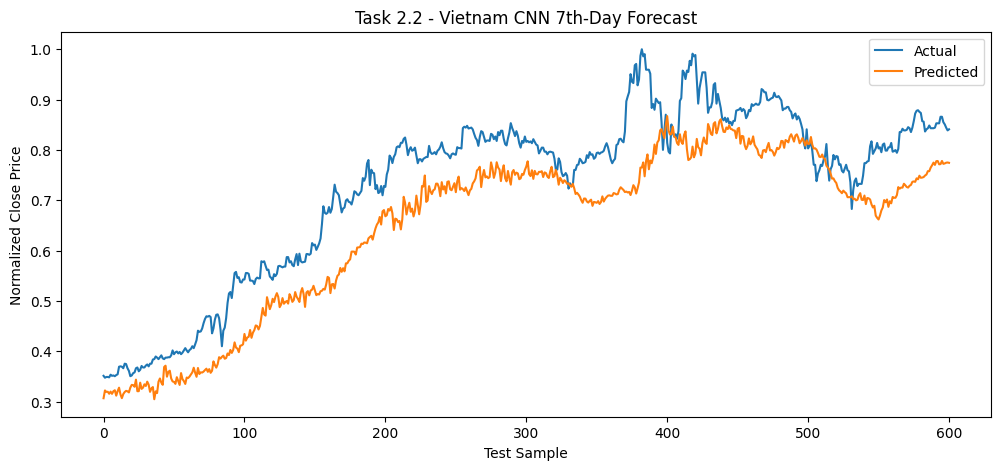

In [19]:
plot_training_history(
    history_2_2,
    f"Task 2.2 - Vietnam CNN {k_day}th-Day Forecast Loss",
    "../results/figures/task2_2_cnn_loss_curve.png"
)

pred_2_2 = model_2_2.predict(X_test_2_2)

rmse_2_2, mae_2_2 = evaluate_prediction(
    y_test_2_2,
    pred_2_2,
    f"Task 2.2 - Vietnam CNN {k_day}th-Day Forecast",
    "../results/figures/task2_2_cnn_actual_vs_predicted.png"
)

model_2_2.save("../models/task2_2_vietnam_cnn_kth_day.keras")

In [20]:
# ============================================================
# Task 2.3 - Vietnam k consecutive days forecast
# ============================================================

def create_k_days_dataset(
    scaled_data,
    window_size,
    close_index,
    k
):
    X = []
    y = []

    for i in range(window_size, len(scaled_data) - k + 1):
        X.append(
            scaled_data[i - window_size:i]
        )

        y.append(
            scaled_data[i:i + k, close_index]
        )

    return np.array(X), np.array(y)

In [21]:
k_days = 7

X_2_3, y_2_3 = create_k_days_dataset(
    scaled_data=scaled_data,
    window_size=window_size,
    close_index=close_index,
    k=k_days
)

print("Task 2.3 X shape:", X_2_3.shape)
print("Task 2.3 y shape:", y_2_3.shape)

Task 2.3 X shape: (4002, 30, 5)
Task 2.3 y shape: (4002, 7)


In [22]:
X_train_2_3, X_val_2_3, X_test_2_3, \
y_train_2_3, y_val_2_3, y_test_2_3 = chronological_split(
    X_2_3,
    y_2_3
)

print("Train:", X_train_2_3.shape, y_train_2_3.shape)
print("Validation:", X_val_2_3.shape, y_val_2_3.shape)
print("Test:", X_test_2_3.shape, y_test_2_3.shape)

Train: (2801, 30, 5) (2801, 7)
Validation: (600, 30, 5) (600, 7)
Test: (601, 30, 5) (601, 7)


In [23]:
model_2_3 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=k_days
)

model_2_3.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,887 (230.03 KB)

 Trainable params: 58,887 (230.03 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_2_3 = model_2_3.fit(
    X_train_2_3,
    y_train_2_3,
    validation_data=(
        X_val_2_3,
        y_val_2_3
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0017 - mae: 0.0264 - val_loss: 7.1774e-04 - val_mae: 0.0220
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8529e-04 - mae: 0.0172 - val_loss: 9.5423e-04 - val_mae: 0.0266
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.7874e-04 - mae: 0.0143 - val_loss: 4.2753e-04 - val_mae: 0.0171
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7128e-04 - mae: 0.0126 - val_loss: 7.9032e-04 - val_mae: 0.0245
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.4099e-04 - mae: 0.0119 - val_loss: 3.0868e-04 - val_mae: 0.0135
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.6705e-04 - mae: 0.0107 - val_loss: 3.5797e-04 - val_mae: 0.0155
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4253e-04 - mae: 0.0101 - val_loss: 5.8261e-04 - val_mae: 0.0208
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1144e-04 - mae: 0.0095 - val_loss: 4.5452e-04 - val_mae: 0.0180


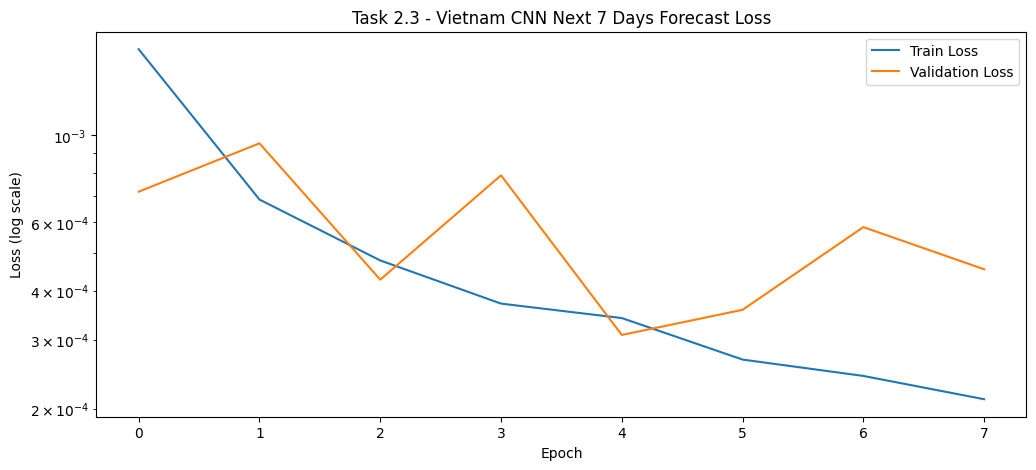

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Task 2.3 - Vietnam CNN Next 7 Days Forecast
RMSE: 0.08562199159424239
MAE: 0.07221549727125173


In [25]:
plot_training_history(
    history_2_3,
    f"Task 2.3 - Vietnam CNN Next {k_days} Days Forecast Loss",
    "../results/figures/task2_3_cnn_loss_curve.png"
)

pred_2_3 = model_2_3.predict(X_test_2_3)

rmse_2_3 = np.sqrt(
    mean_squared_error(
        y_test_2_3.flatten(),
        pred_2_3.flatten()
    )
)

mae_2_3 = mean_absolute_error(
    y_test_2_3.flatten(),
    pred_2_3.flatten()
)

print(f"Task 2.3 - Vietnam CNN Next {k_days} Days Forecast")
print("RMSE:", rmse_2_3)
print("MAE:", mae_2_3)

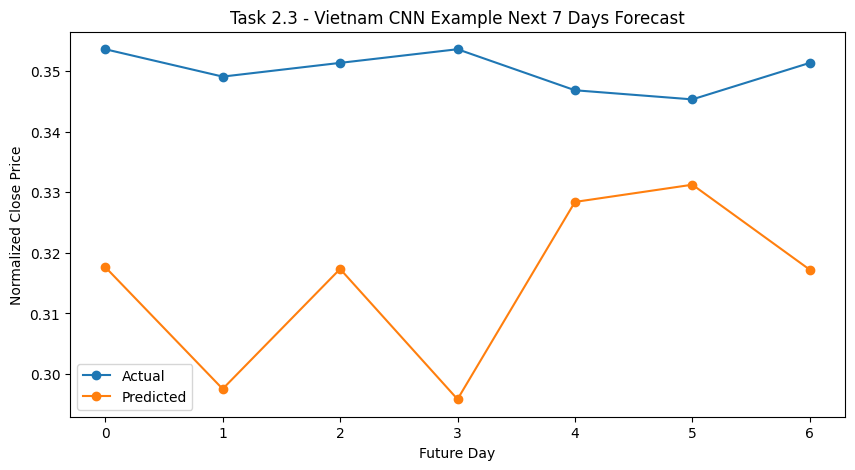

In [26]:
sample_index = 0

plt.figure(figsize=(10, 5))

plt.plot(
    y_test_2_3[sample_index],
    marker="o",
    label="Actual"
)

plt.plot(
    pred_2_3[sample_index],
    marker="o",
    label="Predicted"
)

plt.title(f"Task 2.3 - Vietnam CNN Example Next {k_days} Days Forecast")
plt.xlabel("Future Day")
plt.ylabel("Normalized Close Price")
plt.legend()

plt.savefig(
    "../results/figures/task2_3_cnn_example_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

model_2_3.save("../models/task2_3_vietnam_cnn_k_days.keras")

In [27]:
# ============================================================
# Final Task 2 results
# ============================================================

task2_results = pd.DataFrame({
    "Task": [
        "Task 2.1 - Next-day prediction",
        f"Task 2.2 - {k_day}th day prediction",
        f"Task 2.3 - Next {k_days} days prediction"
    ],
    "Model": [
        "CNN",
        "CNN",
        "CNN"
    ],
    "RMSE": [
        rmse_2_1,
        rmse_2_2,
        rmse_2_3
    ],
    "MAE": [
        mae_2_1,
        mae_2_2,
        mae_2_3
    ]
})

task2_results

,Task,Model,RMSE,MAE
0,Task 2.1 - Next-day prediction,CNN,0.046507,0.037611
1,Task 2.2 - 7th day prediction,CNN,0.092521,0.080856
2,Task 2.3 - Next 7 days prediction,CNN,0.085622,0.072215


In [28]:
task2_results.to_csv(
    "../results/metrics/task2_vietnam_metrics.csv",
    index=False
)

task2_results_rounded = task2_results.copy()

task2_results_rounded["RMSE"] = task2_results_rounded["RMSE"].round(4)
task2_results_rounded["MAE"] = task2_results_rounded["MAE"].round(4)

task2_results_rounded.to_csv(
    "../results/tables/task2_vietnam_results_table.csv",
    index=False
)

task2_results_rounded

,Task,Model,RMSE,MAE
0,Task 2.1 - Next-day prediction,CNN,0.0465,0.0376
1,Task 2.2 - 7th day prediction,CNN,0.0925,0.0809
2,Task 2.3 - Next 7 days prediction,CNN,0.0856,0.0722
